In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = '''
SELECT
    uid,
    timestamp,
    COUNT(*) AS commits
FROM
    checker
WHERE
    status = 'ready'
    AND uid LIKE 'user_%'
    AND labname = 'project1'
GROUP BY
    uid, timestamp
'''

In [4]:
df = pd.read_sql(query, conn)

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values(by=['uid','timestamp'], inplace=True)
df['cumulative_commits'] = df.groupby('uid')['commits'].cumsum()

In [6]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

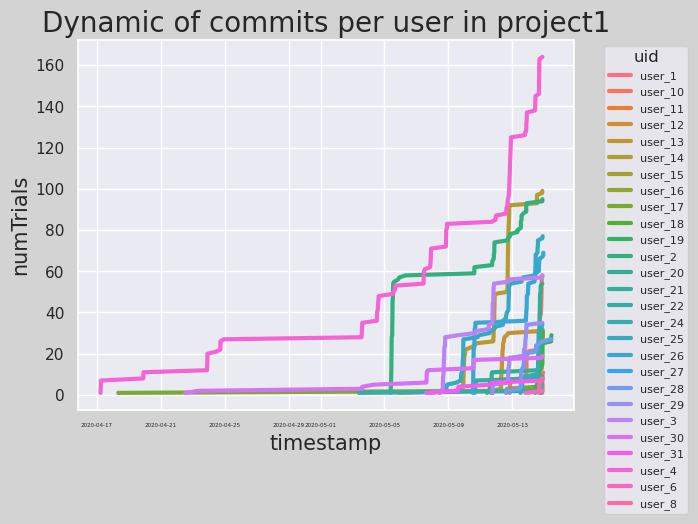

In [7]:
sns.lineplot(
    data=df,
    x="timestamp",
    y="cumulative_commits",
    hue="uid",
    linewidth=3,
    palette="husl"
)

plt.title("Dynamic of commits per user in project1", fontsize=20)
plt.xticks(fontsize=4)
plt.xlabel("timestamp", fontsize=15)
plt.ylabel("numTrials", fontsize=15)
plt.legend(title="uid", bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8})
plt.gcf().set_facecolor('lightgray')

In [8]:
conn.close()

## Which user was the leader in the number of commits almost all of the time?

Answer: user_4.

## Which user was the leader for only a short period of time?

Answer: user_2.